# Análisis estadístico — Arreglo factorial UV-C bajo efectos fijos, aleatorios y mixtos

**Reanálisis del experimento de inactivación de *E. coli* y *S. typhimurium* mediante radiación UV-C,
formulado como un arreglo factorial $2\times3\times3$ y resuelto bajo las tres condiciones del modelo
lineal.**

Curso: *Métodos Estadísticos para Investigaciones Experimentales* — Escuela de Posgrado, UNT.

Esta segunda resolución parte del mismo conjunto de datos del primer examen, pero se centra en el
**diseño factorial** y lo desarrolla bajo las **tres condiciones** indicadas en `condiciones.txt`:

1. **Modelo I — Efectos fijos:** los niveles de cada factor son los únicos de interés.
2. **Modelo II — Efectos aleatorios:** los niveles son una muestra de una población de niveles.
3. **Modelo III — Efectos mixtos:** unos factores son fijos y otros aleatorios.

La diferencia entre los tres modelos **no** está en las sumas de cuadrados (que son las mismas), sino
en los **cuadrados medios esperados (EMS)**, que determinan **qué término es el denominador correcto
de cada prueba $F$**. Finalmente se selecciona el mejor modelo factorial y se compara con la mejor
opción de **DCA** obtenida en el primer examen.

Cada sección sigue el mismo esquema de trabajo del primer informe: **(1)** preparar o resumir los
datos, **(2)** ejecutar el modelo o gráfico y **(3)** interpretar el resultado.

> Factores: $A$ = microorganismo (2 niveles), $B$ = tiempo (1, 3, 5 min), $C$ = altura (5, 10, 20 cm),
> con $n=4$ repeticiones ($N=72$). Variable respuesta: recuento de sobrevivientes en placa (UFC).

## 1. Configuración del entorno

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.graphics.factorplots import interaction_plot
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import os, warnings
from IPython import get_ipython
from IPython.display import display, Image

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
FIG = "figuras"
os.makedirs(FIG, exist_ok=True)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
ip = get_ipython()
if ip is not None:
    try:
        ip.run_line_magic("matplotlib", "inline")
    except Exception:
        pass

def guardar_y_mostrar(fig, nombre):
    ruta = os.path.join(FIG, nombre)
    fig.savefig(ruta, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=ruta))
    return ruta

print("Entorno listo. Figuras ->", os.path.abspath(FIG))

Entorno listo. Figuras -> D:\Desarrollo\Maestria\examen\resolucion_factorial\codigo\figuras


## Antecedente — modelos del primer examen

El primer examen evaluó **seis modelos**; esta resolución retoma el **arreglo factorial**
(modelos 5 y 6) y lo profundiza bajo efectos fijos, aleatorios y mixtos. La siguiente tabla los
resume; más adelante se compara el mejor modelo factorial con la mejor opción de **DCA** (modelo 2).

In [2]:
resumen_examen1 = pd.DataFrame([
 ["1. Preexperimental","Y=μ+τ (ctrl vs tratado)","UV-C reduce la carga ~95% (t de Welch, p<0.001)","Insuficiente: no evalúa tiempo/altura/interacción"],
 ["2. DCA","Y=μ+τ (9 tratamientos)","Tratamientos signif. (F=23.45 y 26.42; p<0.001)","Válido, pero no separa los efectos"],
 ["3. DBCA","Y=μ+τ+β (bloque=réplica)","Bloques NO signif. (p=0.59 y 0.76)","No mejora al DCA; bloqueo injustificado"],
 ["4. Cuadrado latino","Y=μ+τ+ρ+γ","Confundiría la interacción (141.3) con el error","Inaplicable: tiempo y altura son factores"],
 ["5. Factorial 3×3 (por microorg.)","Y=μ+α+β+(αβ)","Tiempo, altura e interacción signif. (R²≈0.88)","Muy adecuado por microorganismo"],
 ["6. Factorial 2×3×3","Modelo completo (A*B*C)","Signif. A, B, C, A×B y dominante B×C (F=52.76)","RECOMENDADO (el más completo)"],
], columns=["Modelo","Modelo estadístico","Resultado principal","Veredicto"])
resumen_examen1.set_index("Modelo")

,Modelo estadístico,Resultado principal,Veredicto
Modelo,,,
1. Preexperimental,Y=μ+τ (ctrl vs tratado),"UV-C reduce la carga ~95% (t de Welch, p<0.001)",Insuficiente: no evalúa tiempo/altura/interacción
2. DCA,Y=μ+τ (9 tratamientos),Tratamientos signif. (F=23.45 y 26.42; p<0.001),"Válido, pero no separa los efectos"
3. DBCA,Y=μ+τ+β (bloque=réplica),Bloques NO signif. (p=0.59 y 0.76),No mejora al DCA; bloqueo injustificado
4. Cuadrado latino,Y=μ+τ+ρ+γ,Confundiría la interacción (141.3) con el error,Inaplicable: tiempo y altura son factores
5. Factorial 3×3 (por microorg.),Y=μ+α+β+(αβ),"Tiempo, altura e interacción signif. (R²≈0.88)",Muy adecuado por microorganismo
6. Factorial 2×3×3,Modelo completo (A*B*C),"Signif. A, B, C, A×B y dominante B×C (F=52.76)",RECOMENDADO (el más completo)


## 2. Carga de los datos (formato *tidy*)

**Paso 1.** Reutilizar el archivo `datos_uvc.csv` del primer examen (72 observaciones tratadas).

**Paso 2.** Confirmar la estructura del arreglo factorial: $2\times3\times3$ con 4 réplicas.

**Paso 3.** Guardar las constantes del diseño ($a,b,c,n$) que intervienen en los EMS.

In [3]:
df = pd.read_csv("datos_uvc.csv")
control = {"E. coli":[225,240,245,230], "S. typhimurium":[247,245,236,233]}
N0 = {org: np.mean(v) for org, v in control.items()}

a = df.microorganismo.nunique()   # niveles de A (microorganismo) = 2
b = df.tiempo.nunique()           # niveles de B (tiempo)         = 3
c = df.altura.nunique()           # niveles de C (altura)         = 3
n = df.groupby(["microorganismo","tiempo","altura"]).size().min()  # replicas = 4
print(f"a (microorganismo) = {a} | b (tiempo) = {b} | c (altura) = {c} | n (replicas) = {n}")
print(f"N total = {len(df)}  (esperado {a*b*c*n})")
df.head(8)

a (microorganismo) = 2 | b (tiempo) = 3 | c (altura) = 3 | n (replicas) = 4
N total = 72  (esperado 72)


,microorganismo,tiempo,altura,rep,recuento,trat
0,E. coli,1,5,1,10,T1_H5
1,E. coli,1,5,2,8,T1_H5
2,E. coli,1,5,3,9,T1_H5
3,E. coli,1,5,4,11,T1_H5
4,E. coli,1,10,1,12,T1_H10
5,E. coli,1,10,2,13,T1_H10
6,E. coli,1,10,3,12,T1_H10
7,E. coli,1,10,4,11,T1_H10


## 3. ANOVA factorial base $2\times3\times3$ (descomposición común)

**Paso 1.** Ajustar el modelo factorial completo con todos los efectos principales e interacciones.

**Paso 2.** Extraer, para cada término, la suma de cuadrados (SC), los grados de libertad (gl) y el
cuadrado medio (CM). El diseño es **balanceado**, por lo que la descomposición es ortogonal
(SC tipo I = II = III).

**Paso 3.** Estos cuadrados medios son el **insumo común** de los tres modelos (fijos, aleatorios y
mixtos): lo único que cambiará entre modelos es el **denominador** de cada $F$.

$$Y_{ijkl} = \mu + A_i + B_j + C_k + (AB)_{ij} + (AC)_{ik} + (BC)_{jk} + (ABC)_{ijk} + \varepsilon_{ijkl}$$

In [4]:
modelo = ols("recuento ~ C(microorganismo)*C(tiempo)*C(altura)", data=df).fit()
tab = anova_lm(modelo, typ=2)
print("ANOVA factorial 2x3x3 (descomposicion de SC)")
print(tab.round(4))
print(f"\nR^2 = {modelo.rsquared:.4f} | R^2 ajustado = {modelo.rsquared_adj:.4f}")

# Diccionario compacto de SC, gl y CM por termino
key = {"A":"C(microorganismo)", "B":"C(tiempo)", "C":"C(altura)",
       "AB":"C(microorganismo):C(tiempo)", "AC":"C(microorganismo):C(altura)",
       "BC":"C(tiempo):C(altura)", "ABC":"C(microorganismo):C(tiempo):C(altura)",
       "E":"Residual"}
SC = {k: tab.loc[v,"sum_sq"] for k,v in key.items()}
GL = {k: int(tab.loc[v,"df"]) for k,v in key.items()}
MS = {k: SC[k]/GL[k] for k in SC}
etq = {"A":"A: microorganismo", "B":"B: tiempo", "C":"C: altura",
       "AB":"A×B", "AC":"A×C", "BC":"B×C (tiempo×altura)", "ABC":"A×B×C", "E":"Error"}
pd.DataFrame({"Fuente":[etq[k] for k in key],
              "SC":[round(SC[k],3) for k in key],
              "gl":[GL[k] for k in key],
              "CM":[round(MS[k],4) for k in key]}).set_index("Fuente")

ANOVA factorial 2x3x3 (descomposicion de SC)
                                        sum_sq      df       F  PR(>F)
C(microorganismo)                      19.0139  1.0000 10.6124  0.0019
C(tiempo)                             172.1944  2.0000 48.0543  0.0000
C(altura)                             117.3611  2.0000 32.7519  0.0000
C(microorganismo):C(tiempo)            44.5278  2.0000 12.4264  0.0000
C(microorganismo):C(altura)             1.6944  2.0000  0.4729  0.6258
C(tiempo):C(altura)                   378.1389  4.0000 52.7636  0.0000
C(microorganismo):C(tiempo):C(altura)   9.6389  4.0000  1.3450  0.2653
Residual                               96.7500 54.0000     NaN     NaN

R^2 = 0.8847 | R^2 ajustado = 0.8484


,SC,gl,CM
Fuente,,,
A: microorganismo,19.0140,1,19.0139
B: tiempo,172.1940,2,86.0972
C: altura,117.3610,2,58.6806
A×B,44.5280,2,22.2639
A×C,1.6940,2,0.8472
B×C (tiempo×altura),378.1390,4,94.5347
A×B×C,9.6390,4,2.4097
Error,96.7500,54,1.7917


## 4. Marco teórico: cuadrados medios esperados (EMS)

La elección **fijos / aleatorios / mixtos** cambia la esperanza de cada cuadrado medio y, por tanto,
el **denominador** correcto de la prueba $F$. Para un factorial de tres factores con $n$ réplicas:

**Modelo I — efectos fijos** ($A,B,C$ fijos). Todo efecto se contrasta contra el **error**:
$$E(CM_{efecto}) = \sigma^2 + (\text{forma cuadrática del efecto}) \;\Rightarrow\; F=\frac{CM_{efecto}}{CM_{error}}.$$

**Modelo II — efectos aleatorios** ($A,B,C$ aleatorios). Las interacciones entran en los EMS de los
efectos que contienen:
$$
F_{ABC}=\frac{CM_{ABC}}{CM_{E}},\quad
F_{AB}=\frac{CM_{AB}}{CM_{ABC}},\ F_{AC}=\frac{CM_{AC}}{CM_{ABC}},\ F_{BC}=\frac{CM_{BC}}{CM_{ABC}},
$$
y los **efectos principales no tienen prueba $F$ exacta**: se usa un denominador sintético de
**Satterthwaite**, p. ej. $F_A = CM_A/(CM_{AB}+CM_{AC}-CM_{ABC})$.

**Modelo III — efectos mixtos** (aquí $A$ = microorganismo **fijo**; $B$ = tiempo y $C$ = altura
**aleatorios**; modelo restringido):
$$
F_A=\frac{CM_A}{CM_{AB}+CM_{AC}-CM_{ABC}},\quad
F_B=\frac{CM_B}{CM_{BC}},\ F_C=\frac{CM_C}{CM_{BC}},
$$
$$
F_{AB}=\frac{CM_{AB}}{CM_{ABC}},\ F_{AC}=\frac{CM_{AC}}{CM_{ABC}},\quad
F_{BC}=\frac{CM_{BC}}{CM_{E}},\ F_{ABC}=\frac{CM_{ABC}}{CM_{E}}.
$$

A continuación se definen utilidades para construir cualquier tabla $F$ a partir de los cuadrados
medios y de un denominador (simple o sintético).

In [5]:
# F y p con denominador = un solo cuadrado medio
def f_simple(num, den):
    F = MS[num]/MS[den]
    p = stats.f.sf(F, GL[num], GL[den])
    return F, GL[num], GL[den], p

# F con denominador sintetico = sum(CM[mas]) - sum(CM[menos]); gl de Satterthwaite
def f_satterthwaite(num, mas, menos):
    den = sum(MS[t] for t in mas) - sum(MS[t] for t in menos)
    gl_den = den**2 / sum((MS[t]**2)/GL[t] for t in (mas+menos))
    F = MS[num]/den
    p = stats.f.sf(F, GL[num], gl_den)
    return F, GL[num], gl_den, p, den

# filas: lista de (etiqueta, F, gl1, gl2, p, denom_txt)
def tabla_F(filas):
    out = pd.DataFrame(filas, columns=["Fuente","F","gl_num","gl_den","p-valor","Denominador"])
    out["signif."] = np.where(out["p-valor"]<0.05, "*", "ns")
    out["F"] = out["F"].round(3); out["gl_den"] = out["gl_den"].round(2)
    out["p-valor"] = out["p-valor"].map(lambda x: f"{x:.4g}")
    return out.set_index("Fuente")
print("Utilidades EMS listas.")

Utilidades EMS listas.


## 5. Modelo I — Efectos fijos

**Paso 1.** Suponer que los **dos** microorganismos, los **tres** tiempos y las **tres** alturas son
los únicos niveles de interés (elegidos deliberadamente por el investigador).

**Paso 2.** Contrastar **todos** los efectos contra el cuadrado medio del error.

**Paso 3.** Interpretar qué factores e interacciones son significativos.

**Hipótesis** (forma genérica): $H_0:$ todos los efectos del término son nulos vs. $H_1:$ al menos
uno es distinto de cero.

In [6]:
filas_fijos = []
for k in ["A","B","C","AB","AC","BC","ABC"]:
    F,g1,g2,p = f_simple(k,"E")
    filas_fijos.append([etq[k], F, g1, g2, p, "CM_error"])
T1 = tabla_F(filas_fijos)
print("MODELO I — EFECTOS FIJOS (todo contra el error)")
T1

MODELO I — EFECTOS FIJOS (todo contra el error)


,F,gl_num,gl_den,p-valor,Denominador,signif.
Fuente,,,,,,
A: microorganismo,10.6120,1,54,0.001945,CM_error,*
B: tiempo,48.0540,2,54,1.027e-12,CM_error,*
C: altura,32.7520,2,54,4.845e-10,CM_error,*
A×B,12.4260,2,54,3.636e-05,CM_error,*
A×C,0.4730,2,54,0.6258,CM_error,ns
B×C (tiempo×altura),52.7640,4,54,4.975e-18,CM_error,*
A×B×C,1.3450,4,54,0.2653,CM_error,ns


**Interpretación.** Son significativos el microorganismo, el tiempo, la altura, la interacción
microorganismo×tiempo y, de forma **dominante**, la interacción **tiempo×altura** ($F\approx52.8$).
No son significativas microorganismo×altura ni la interacción triple. Este modelo coincide con el
modelo factorial recomendado del primer examen.

## 6. Modelo II — Efectos aleatorios

**Paso 1.** Suponer que los niveles de **cada** factor son una muestra aleatoria de una población de
niveles posibles (otros microorganismos, otros tiempos, otras alturas).

**Paso 2.** Construir las pruebas $F$ con los denominadores que imponen los EMS: las interacciones
dobles se prueban contra la triple, la triple contra el error y los efectos principales con
**denominadores sintéticos de Satterthwaite**.

**Paso 3.** Estimar los **componentes de varianza** por el método de los momentos (igualando CM a EMS).

In [7]:
filas_aleat = [
    [etq["ABC"], *f_simple("ABC","E"), "CM_E"],
    [etq["AB"],  *f_simple("AB","ABC"), "CM_ABC"],
    [etq["AC"],  *f_simple("AC","ABC"), "CM_ABC"],
    [etq["BC"],  *f_simple("BC","ABC"), "CM_ABC"],
]
for k,(mas,menos,txt) in {"A":(["AB","AC"],["ABC"],"CM_AB+CM_AC-CM_ABC"),
                          "B":(["AB","BC"],["ABC"],"CM_AB+CM_BC-CM_ABC"),
                          "C":(["AC","BC"],["ABC"],"CM_AC+CM_BC-CM_ABC")}.items():
    F,g1,g2,p,den = f_satterthwaite(k,mas,menos)
    filas_aleat.append([etq[k], F, g1, g2, p, txt])
orden = ["A: microorganismo","B: tiempo","C: altura","A×B","A×C","B×C (tiempo×altura)","A×B×C"]
T2 = tabla_F(filas_aleat).reindex(orden)
print("MODELO II — EFECTOS ALEATORIOS (denominadores segun EMS)")
T2

MODELO II — EFECTOS ALEATORIOS (denominadores segun EMS)


,F,gl_num,gl_den,p-valor,Denominador,signif.
Fuente,,,,,,
A: microorganismo,0.9180,1,1.7200,0.4529,CM_AB+CM_AC-CM_ABC,ns
B: tiempo,0.7530,2,5.2700,0.5158,CM_AB+CM_BC-CM_ABC,ns
C: altura,0.6310,2,3.8700,0.5792,CM_AC+CM_BC-CM_ABC,ns
A×B,9.2390,2,4.0000,0.03167,CM_ABC,*
A×C,0.3520,2,4.0000,0.7233,CM_ABC,ns
B×C (tiempo×altura),39.2310,4,4.0000,0.001823,CM_ABC,*
A×B×C,1.3450,4,54.0000,0.2653,CM_E,ns


In [8]:
# Componentes de varianza (metodo de los momentos, modelo aleatorio)
vc = {}
vc["sigma2_A"]   = (MS["A"]   - MS["AB"] - MS["AC"] + MS["ABC"]) / (b*c*n)
vc["sigma2_B"]   = (MS["B"]   - MS["AB"] - MS["BC"] + MS["ABC"]) / (a*c*n)
vc["sigma2_C"]   = (MS["C"]   - MS["AC"] - MS["BC"] + MS["ABC"]) / (a*b*n)
vc["sigma2_AB"]  = (MS["AB"]  - MS["ABC"]) / (c*n)
vc["sigma2_AC"]  = (MS["AC"]  - MS["ABC"]) / (b*n)
vc["sigma2_BC"]  = (MS["BC"]  - MS["ABC"]) / (a*n)
vc["sigma2_ABC"] = (MS["ABC"] - MS["E"])   / n
vc["sigma2_error"] = MS["E"]
vc_df = pd.DataFrame({"Componente": list(vc.keys()),
                      "Estimacion": [round(v,4) for v in vc.values()]})
vc_df["Truncado(>=0)"] = vc_df["Estimacion"].clip(lower=0)
tot = vc_df["Truncado(>=0)"].sum()
vc_df["% del total"] = (100*vc_df["Truncado(>=0)"]/tot).round(1)
print("Componentes de varianza (modelo aleatorio). Negativo => se interpreta como 0.")
vc_df.set_index("Componente")

Componentes de varianza (modelo aleatorio). Negativo => se interpreta como 0.


,Estimacion,Truncado(>=0),% del total
Componente,,,
sigma2_A,-0.0469,0.0000,0.0000
sigma2_B,-1.1788,0.0000,0.0000
sigma2_C,-1.4288,0.0000,0.0000
sigma2_AB,1.6545,1.6545,10.9000
sigma2_AC,-0.1302,0.0000,0.0000
sigma2_BC,11.5156,11.5156,76.2000
sigma2_ABC,0.1545,0.1545,1.0000
sigma2_error,1.7917,1.7917,11.9000


**Interpretación.** Bajo el modelo aleatorio cambian radicalmente las conclusiones: los **efectos
principales dejan de ser significativos** (se contrastan contra denominadores grandes con muy pocos
grados de libertad), mientras que la **interacción tiempo×altura** sigue siendo significativa. Varios
componentes de varianza resultan **negativos** (microorganismo, tiempo, altura), señal de que el
supuesto de "niveles aleatorios" **no es coherente** con estos datos: la mayor parte de la varianza
no negativa se concentra en la interacción **tiempo×altura**.

## 7. Modelo III — Efectos mixtos

**Paso 1.** Adoptar el escenario mixto más razonable para este experimento: el **microorganismo $A$
es un factor fijo** (los dos patógenos de interés sanitario), mientras que **tiempo $B$ y altura $C$
se tratan como aleatorios** (una muestra de los posibles ajustes operativos de la cámara UV-C).

**Paso 2.** Aplicar las pruebas $F$ del modelo **mixto restringido**: el efecto fijo $A$ usa un
denominador sintético; los efectos aleatorios $B$ y $C$ se prueban contra $CM_{BC}$; y $BC$ y $ABC$
contra el error.

**Paso 3.** Interpretar y comparar con los modelos I y II.

In [9]:
filas_mix = []
F,g1,g2,p,den = f_satterthwaite("A",["AB","AC"],["ABC"])
filas_mix.append([etq["A"], F,g1,g2,p, "CM_AB+CM_AC-CM_ABC"])
filas_mix += [
    [etq["B"],   *f_simple("B","BC"),   "CM_BC"],
    [etq["C"],   *f_simple("C","BC"),   "CM_BC"],
    [etq["AB"],  *f_simple("AB","ABC"), "CM_ABC"],
    [etq["AC"],  *f_simple("AC","ABC"), "CM_ABC"],
    [etq["BC"],  *f_simple("BC","E"),   "CM_E"],
    [etq["ABC"], *f_simple("ABC","E"),  "CM_E"],
]
T3 = tabla_F(filas_mix).reindex(orden)
print("MODELO III — EFECTOS MIXTOS (A fijo; B,C aleatorios; restringido)")
T3

MODELO III — EFECTOS MIXTOS (A fijo; B,C aleatorios; restringido)


,F,gl_num,gl_den,p-valor,Denominador,signif.
Fuente,,,,,,
A: microorganismo,0.9180,1,1.7200,0.4529,CM_AB+CM_AC-CM_ABC,ns
B: tiempo,0.9110,2,4.0000,0.4721,CM_BC,ns
C: altura,0.6210,2,4.0000,0.5824,CM_BC,ns
A×B,9.2390,2,4.0000,0.03167,CM_ABC,*
A×C,0.3520,2,4.0000,0.7233,CM_ABC,ns
B×C (tiempo×altura),52.7640,4,54.0000,4.975e-18,CM_E,*
A×B×C,1.3450,4,54.0000,0.2653,CM_E,ns


**Interpretación.** En el modelo mixto, la **interacción tiempo×altura vuelve a ser muy
significativa** (se prueba contra el error, $F\approx52.8$), pero los efectos principales tiempo y
altura **no** lo son al contrastarse contra $CM_{BC}$. La interacción microorganismo×tiempo se
mantiene significativa. Es decir: aun cambiando el supuesto sobre los factores, **la interacción
tiempo×altura es el efecto robusto** del experimento.

## 8. Comparación de las tres condiciones

**Paso 1.** Reunir, por efecto, el valor $F$ y su decisión bajo los tres modelos.

**Paso 2.** Visualizar cómo cambia la significancia según el supuesto fijos/aleatorios/mixtos.

**Paso 3.** Identificar los efectos robustos (los que se mantienen) frente a los sensibles al supuesto.

In [10]:
def col(tabla):
    return tabla.assign(txt=tabla["F"].astype(str)+" ("+tabla["signif."]+")")["txt"]
comp = pd.DataFrame({
    "Efectos fijos (I)":     col(T1.reindex(orden)),
    "Efectos aleatorios (II)": col(T2.reindex(orden)),
    "Efectos mixtos (III)":  col(T3.reindex(orden)),
})
print("F (signif.) por efecto y condicion   [* = p<0.05, ns = no significativo]")
comp

F (signif.) por efecto y condicion   [* = p<0.05, ns = no significativo]


,Efectos fijos (I),Efectos aleatorios (II),Efectos mixtos (III)
Fuente,,,
A: microorganismo,10.612 (*),0.918 (ns),0.918 (ns)
B: tiempo,48.054 (*),0.753 (ns),0.911 (ns)
C: altura,32.752 (*),0.631 (ns),0.621 (ns)
A×B,12.426 (*),9.239 (*),9.239 (*)
A×C,0.473 (ns),0.352 (ns),0.352 (ns)
B×C (tiempo×altura),52.764 (*),39.231 (*),52.764 (*)
A×B×C,1.345 (ns),1.345 (ns),1.345 (ns)


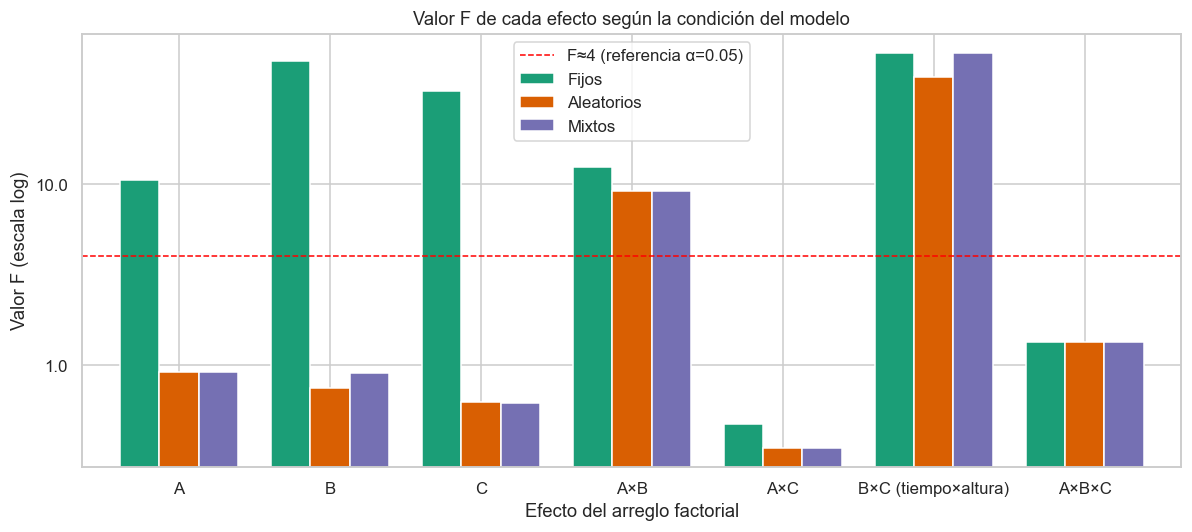

'figuras\\03_F_por_condicion.png'

In [11]:
# Figura: F por efecto bajo cada condicion (escala log; linea = F critico aprox.)
import matplotlib.ticker as mticker
Fvals = pd.DataFrame({
    "Fijos":     [T1.reindex(orden).loc[e,"F"] for e in orden],
    "Aleatorios":[T2.reindex(orden).loc[e,"F"] for e in orden],
    "Mixtos":    [T3.reindex(orden).loc[e,"F"] for e in orden],
}, index=[e.split(":")[0] if ":" in e else e for e in orden])
fig, ax = plt.subplots(figsize=(11,5))
Fvals.plot(kind="bar", ax=ax, width=0.78,
           color=["#1b9e77","#d95f02","#7570b3"])
ax.axhline(4.0, color="red", ls="--", lw=1, label="F≈4 (referencia α=0.05)")
ax.set_yscale("log")
ax.set(title="Valor F de cada efecto según la condición del modelo",
       xlabel="Efecto del arreglo factorial", ylabel="Valor F (escala log)")
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax.tick_params(axis="x", rotation=0)
ax.legend()
plt.tight_layout(); guardar_y_mostrar(fig, "03_F_por_condicion.png")

**Lectura de la figura.** La interacción **tiempo×altura (B×C)** queda muy por encima de la línea
de referencia en los tres modelos: es el efecto **robusto**. En cambio, los efectos principales
tiempo y altura caen por debajo del umbral cuando se les trata como aleatorios o mixtos, porque pasan
a contrastarse contra la propia interacción. Esto demuestra que **la conclusión depende del supuesto
fijos/aleatorios/mixtos**.

## 9. Componentes de varianza e interacción

**Paso 1.** Visualizar el peso de cada componente de varianza (modelo aleatorio).

**Paso 2.** Mostrar el gráfico de interacción tiempo×altura, que es el efecto dominante.

**Paso 3.** Confirmar visualmente por qué el experimento gira en torno a esa interacción.

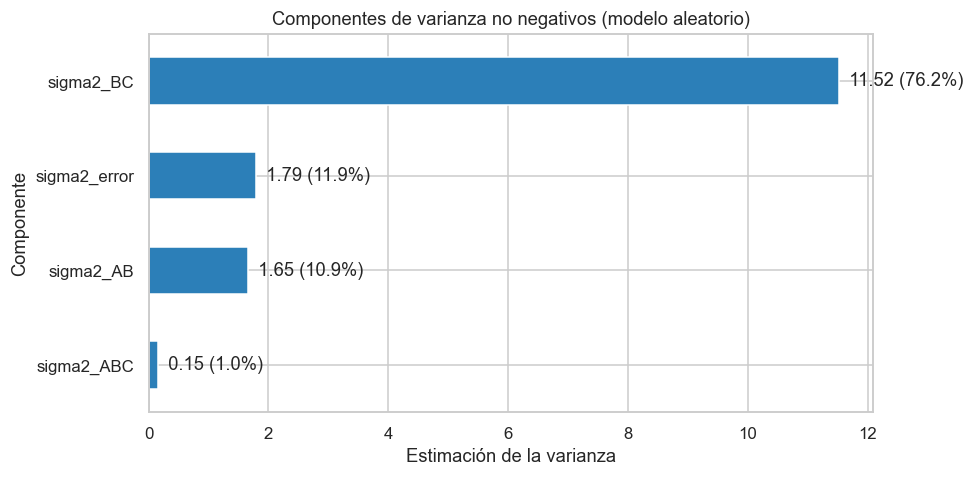

'figuras\\04_componentes_varianza.png'

In [12]:
# Componentes de varianza no negativos
vc_pos = vc_df.set_index("Componente")["Truncado(>=0)"]
vc_pos = vc_pos[vc_pos>0].sort_values()
fig, ax = plt.subplots(figsize=(9,4.5))
vc_pos.plot(kind="barh", ax=ax, color="#2c7fb8")
for i,(name,val) in enumerate(vc_pos.items()):
    ax.text(val, i, f"  {val:.2f} ({100*val/vc_pos.sum():.1f}%)", va="center")
ax.set(title="Componentes de varianza no negativos (modelo aleatorio)",
       xlabel="Estimación de la varianza", ylabel="Componente")
plt.tight_layout(); guardar_y_mostrar(fig, "04_componentes_varianza.png")

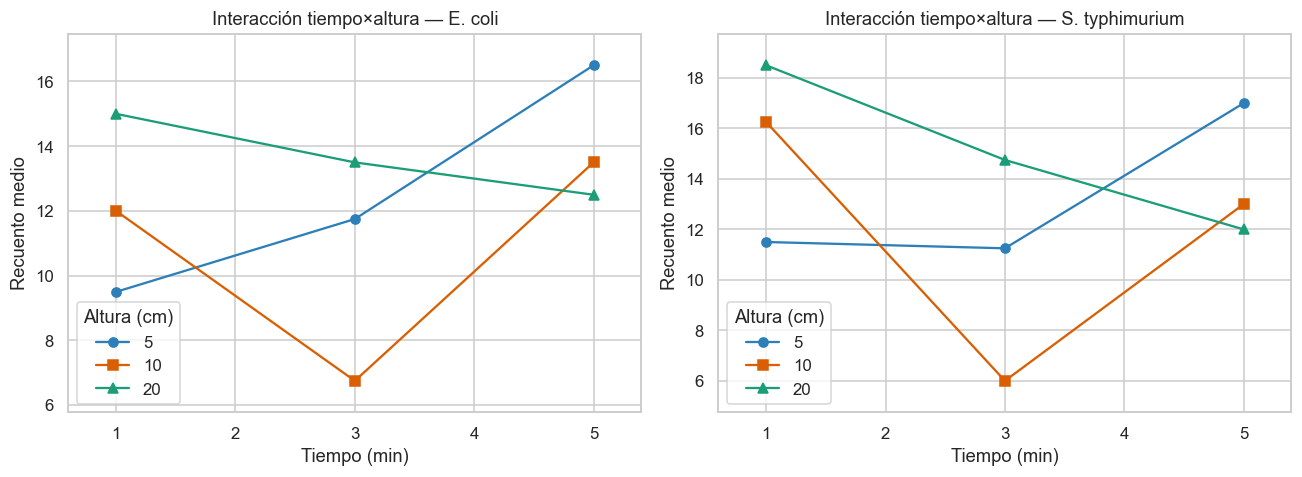

'figuras\\05_interaccion_tiempo_altura.png'

In [13]:
# Grafico de interaccion tiempo x altura por microorganismo
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
for ax, org in zip(axes, df.microorganismo.unique()):
    sub = df[df.microorganismo==org]
    interaction_plot(x=sub.tiempo.values, trace=sub.altura.values, response=sub.recuento.values,
                     ax=ax, markers=["o","s","^"], colors=["#2c7fb8","#d95f02","#1b9e77"])
    ax.set(title=f"Interacción tiempo×altura — {org}", xlabel="Tiempo (min)", ylabel="Recuento medio")
    ax.legend(title="Altura (cm)")
plt.tight_layout(); guardar_y_mostrar(fig, "05_interaccion_tiempo_altura.png")

## 10. Selección del mejor modelo factorial

**Paso 1.** Confrontar los tres modelos con criterios estadísticos y de pertinencia científica.

**Paso 2.** Justificar la elección.

**Paso 3.** Dejar fijado el modelo ganador para compararlo con el DCA del primer examen.

In [14]:
seleccion = pd.DataFrame([
 ["Efectos fijos (I)","Los 2 patógenos, 3 tiempos y 3 alturas son los ÚNICOS de interés (elegidos a propósito)",
  "Todos los efectos vs. error (gl=54): máxima potencia","Coherente: niveles fijados por el investigador","★ RECOMENDADO"],
 ["Efectos aleatorios (II)","Los niveles serían una muestra de poblaciones de niveles",
  "Denominadores con 4 gl y Satterthwaite (~2 gl): poca potencia","Componentes de varianza NEGATIVOS → mal especificado","No adecuado"],
 ["Efectos mixtos (III)","Micro fijo; tiempo y altura aleatorios",
  "Efectos principales vs. CM_BC: poca potencia","Defendible solo si se generaliza a rangos continuos","Parcial / discutible"],
], columns=["Modelo","Supuesto","Comportamiento estadístico","Pertinencia científica","Veredicto"])
seleccion.set_index("Modelo")

,Supuesto,Comportamiento estadístico,Pertinencia científica,Veredicto
Modelo,,,,
Efectos fijos (I),"Los 2 patógenos, 3 tiempos y 3 alturas son los...",Todos los efectos vs. error (gl=54): máxima po...,Coherente: niveles fijados por el investigador,★ RECOMENDADO
Efectos aleatorios (II),Los niveles serían una muestra de poblaciones ...,Denominadores con 4 gl y Satterthwaite (~2 gl)...,Componentes de varianza NEGATIVOS → mal especi...,No adecuado
Efectos mixtos (III),Micro fijo; tiempo y altura aleatorios,Efectos principales vs. CM_BC: poca potencia,Defendible solo si se generaliza a rangos cont...,Parcial / discutible


**Decisión.** El **mejor modelo factorial es el de efectos fijos (Modelo I)**. Los niveles de los
tres factores fueron **seleccionados deliberadamente** (dos patógenos de interés sanitario y valores
concretos de tiempo y altura), por lo que la inferencia se dirige a **esos** niveles, no a una
población. Además, los modelos aleatorio y mixto producen **componentes de varianza negativos** y
denominadores con muy pocos grados de libertad (potencia baja e inestable), lo que confirma que el
supuesto de aleatoriedad no es apropiado para este experimento.

## 11. Comparación: mejor factorial (fijos) vs. mejor DCA del primer examen

**Paso 1.** Recordar la mejor opción del primer examen: el **DCA** que trata las 9 combinaciones
tiempo×altura como 9 tratamientos (ANOVA de una vía), ajustado por microorganismo.

**Paso 2.** Mostrar que el factorial **descompone** la suma de cuadrados de tratamientos del DCA en
efectos principales e interacción, **con el mismo error y el mismo $R^2$**.

**Paso 3.** Concluir cuál es superior y por qué.

In [15]:
print("DCA (una via, 9 tratamientos) vs FACTORIAL 3x3, por microorganismo")
print("="*70)
resumen_cmp = []
for org in df.microorganismo.unique():
    sub = df[df.microorganismo==org]
    m_dca = ols("recuento ~ C(trat)", data=sub).fit()
    t_dca = anova_lm(m_dca, typ=2)
    m_fac = ols("recuento ~ C(tiempo)*C(altura)", data=sub).fit()
    t_fac = anova_lm(m_fac, typ=2)
    sstr = t_dca.loc["C(trat)","sum_sq"]; sse = t_dca.loc["Residual","sum_sq"]
    sct = t_fac.loc["C(tiempo)","sum_sq"]; sca = t_fac.loc["C(altura)","sum_sq"]
    sci = t_fac.loc["C(tiempo):C(altura)","sum_sq"]
    print(f"\n{org}:")
    print(f"  DCA       : SC_trat={sstr:.2f} (gl=8), SSE={sse:.2f} (gl=27), F={t_dca.loc['C(trat)','F']:.2f}, R2={m_dca.rsquared:.4f}")
    print(f"  Factorial : tiempo={sct:.2f} + altura={sca:.2f} + (txa)={sci:.2f} = {sct+sca+sci:.2f}  == SC_trat")
    print(f"              SSE={t_fac.loc['Residual','sum_sq']:.2f}, R2={m_fac.rsquared:.4f}  (identicos al DCA)")
    resumen_cmp.append([org, sstr, sct, sca, sci, sse, m_dca.rsquared])
print("\n>> El factorial CONTIENE al DCA: misma SSE y mismo R2, pero identifica las FUENTES.")

DCA (una via, 9 tratamientos) vs FACTORIAL 3x3, por microorganismo

E. coli:
  DCA       : SC_trat=267.50 (gl=8), SSE=38.50 (gl=27), F=23.45, R2=0.8742
  Factorial : tiempo=74.00 + altura=52.17 + (txa)=141.33 = 267.50  == SC_trat
              SSE=38.50, R2=0.8742  (identicos al DCA)

S. typhimurium:
  DCA       : SC_trat=456.06 (gl=8), SSE=58.25 (gl=27), F=26.42, R2=0.8867
  Factorial : tiempo=142.72 + altura=66.89 + (txa)=246.44 = 456.06  == SC_trat
              SSE=58.25, R2=0.8867  (identicos al DCA)

>> El factorial CONTIENE al DCA: misma SSE y mismo R2, pero identifica las FUENTES.


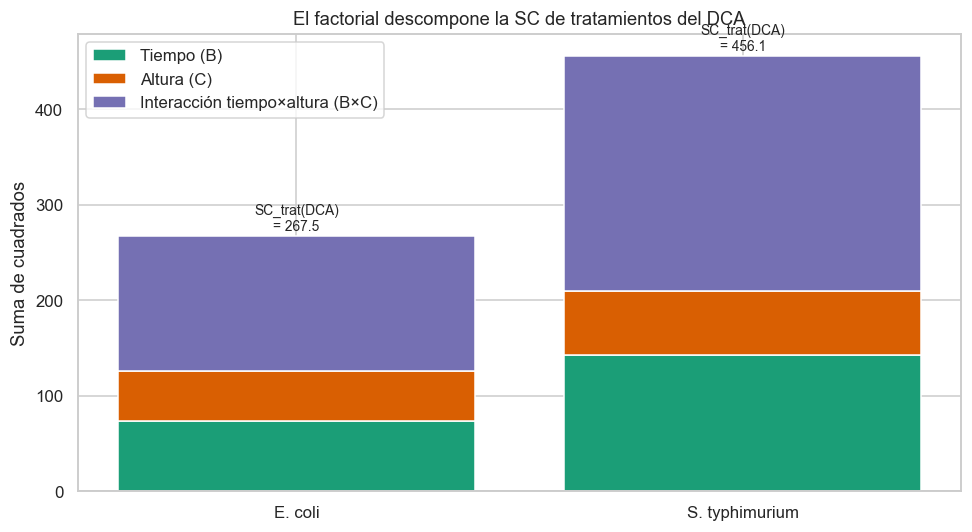

'figuras\\06_factorial_vs_dca.png'

In [16]:
# Figura: descomposicion de la SC de tratamientos del DCA en el factorial
labels = [r[0] for r in resumen_cmp]
tiempo = np.array([r[2] for r in resumen_cmp])
altura = np.array([r[3] for r in resumen_cmp])
inter  = np.array([r[4] for r in resumen_cmp])
fig, ax = plt.subplots(figsize=(9,5))
x = np.arange(len(labels))
ax.bar(x, tiempo, label="Tiempo (B)", color="#1b9e77")
ax.bar(x, altura, bottom=tiempo, label="Altura (C)", color="#d95f02")
ax.bar(x, inter, bottom=tiempo+altura, label="Interacción tiempo×altura (B×C)", color="#7570b3")
for i in range(len(labels)):
    tot = tiempo[i]+altura[i]+inter[i]
    ax.text(i, tot+5, f"SC_trat(DCA)\n= {tot:.1f}", ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set(title="El factorial descompone la SC de tratamientos del DCA",
       ylabel="Suma de cuadrados")
ax.legend()
plt.tight_layout(); guardar_y_mostrar(fig, "06_factorial_vs_dca.png")

In [17]:
comparacion = pd.DataFrame([
 ["DCA (1 vía, 9 tratamientos)","Sí","Detecta diferencias entre tratamientos (p<0.001)",
  "No separa tiempo, altura ni interacción","Válido pero agregado"],
 ["Factorial fijos 2×3×3","Sí","Cuantifica A, B, C y todas las interacciones; misma SSE y R²",
  "Identifica la interacción tiempo×altura (dominante)","★ Superior"],
], columns=["Modelo","Aplicable","Resultado principal","Información sobre los factores","Veredicto"])
comparacion.set_index("Modelo")

,Aplicable,Resultado principal,Información sobre los factores,Veredicto
Modelo,,,,
"DCA (1 vía, 9 tratamientos)",Sí,Detecta diferencias entre tratamientos (p<0.001),"No separa tiempo, altura ni interacción",Válido pero agregado
Factorial fijos 2×3×3,Sí,"Cuantifica A, B, C y todas las interacciones; ...",Identifica la interacción tiempo×altura (domin...,★ Superior


**Conclusión de la comparación.** El factorial de efectos fijos **no compite** con el DCA: lo
**contiene**. La suma de cuadrados de los 9 tratamientos del DCA ($267.50$ en *E. coli*; $456.06$ en
*S. typhimurium*) se descompone exactamente en tiempo + altura + interacción, conservando el mismo
error y el mismo $R^2$. Por tanto, con el **mismo** costo experimental, el factorial entrega **más
información**: revela que el efecto del tiempo depende de la altura. El **factorial de efectos fijos
es el mejor modelo**.

## 12. Validación de supuestos del modelo seleccionado

**Paso 1.** Extraer los residuos del modelo factorial de efectos fijos.

**Paso 2.** Evaluar normalidad (Shapiro–Wilk) y homogeneidad de varianzas (Levene).

**Paso 3.** Acompañar con el diagnóstico gráfico (Q–Q y residuos vs. ajustados).

In [18]:
res = modelo.resid
W,p = stats.shapiro(res)
print(f"Normalidad (Shapiro-Wilk) global: W={W:.4f}, p={p:.4f} -> {'normal' if p>0.05 else 'dudosa'}")
grupos = [g.recuento.values for _,g in df.groupby(['microorganismo','trat'])]
L,p = stats.levene(*grupos, center='median')
print(f"Homogeneidad (Levene, 18 grupos): estadístico={L:.4f}, p={p:.4f} -> {'homogéneas' if p>0.05 else 'heterogéneas'}")

Normalidad (Shapiro-Wilk) global: W=0.9686, p=0.0685 -> normal
Homogeneidad (Levene, 18 grupos): estadístico=0.5472, p=0.9146 -> homogéneas


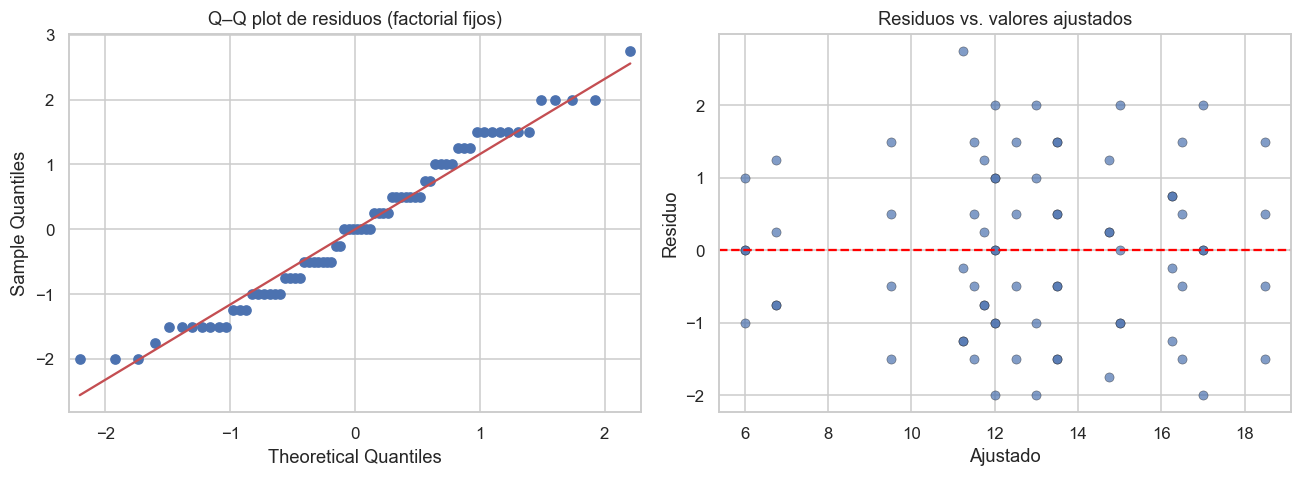

'figuras\\07_diagnostico_residuos.png'

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
sm.qqplot(res, line="s", ax=axes[0])
axes[0].set_title("Q–Q plot de residuos (factorial fijos)")
axes[1].scatter(modelo.fittedvalues, res, alpha=0.7, edgecolor="k", linewidth=0.3)
axes[1].axhline(0, color="red", ls="--")
axes[1].set(title="Residuos vs. valores ajustados", xlabel="Ajustado", ylabel="Residuo")
plt.tight_layout(); guardar_y_mostrar(fig, "07_diagnostico_residuos.png")

## 13. Comparaciones múltiples (Tukey HSD)

**Paso 1.** Dado que la interacción tiempo×altura es significativa, el tratamiento óptimo se
identifica por **combinación de niveles**.

**Paso 2.** Aplicar Tukey sobre los 9 tratamientos por microorganismo.

**Paso 3.** Confirmar el tratamiento de menor recuento.

In [20]:
for org in df.microorganismo.unique():
    sub = df[df.microorganismo==org]
    tuk = pairwise_tukeyhsd(sub.recuento, sub.trat, alpha=0.05)
    medias = sub.groupby("trat").recuento.mean().sort_values()
    print(f"\nTukey HSD — {org}: menor recuento = {medias.index[0]} (media={medias.iloc[0]:.2f}), "
          f"mayor = {medias.index[-1]} (media={medias.iloc[-1]:.2f})")
    print(tuk.summary())


Tukey HSD — E. coli: menor recuento = T3_H10 (media=6.75), mayor = T5_H5 (media=16.50)
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
T1_H10 T1_H20      3.0 0.0326   0.1589  5.8411   True
T1_H10  T1_H5     -2.5  0.118  -5.3411  0.3411  False
T1_H10 T3_H10    -5.25    0.0  -8.0911 -2.4089   True
T1_H10 T3_H20      1.5 0.6961  -1.3411  4.3411  False
T1_H10  T3_H5    -0.25    1.0  -3.0911  2.5911  False
T1_H10 T5_H10      1.5 0.6961  -1.3411  4.3411  False
T1_H10 T5_H20      0.5 0.9995  -2.3411  3.3411  False
T1_H10  T5_H5      4.5 0.0004   1.6589  7.3411   True
T1_H20  T1_H5     -5.5    0.0  -8.3411 -2.6589   True
T1_H20 T3_H10    -8.25    0.0 -11.0911 -5.4089   True
T1_H20 T3_H20     -1.5 0.6961  -4.3411  1.3411  False
T1_H20  T3_H5    -3.25 0.0162  -6.0911 -0.4089   True
T1_H20 T5_H10     -1.5 0.6961  -4.3411  1.3411  False
T1_H20 T5_H20     -2.5  0.118  -5.3411  0.3411  


Tukey HSD — S. typhimurium: menor recuento = T3_H10 (media=6.00), mayor = T1_H20 (media=18.50)
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
T1_H10 T1_H20     2.25 0.4533  -1.2446  5.7446  False
T1_H10  T1_H5    -4.75 0.0026  -8.2446 -1.2554   True
T1_H10 T3_H10   -10.25    0.0 -13.7446 -6.7554   True
T1_H10 T3_H20     -1.5 0.8704  -4.9946  1.9946  False
T1_H10  T3_H5     -5.0 0.0014  -8.4946 -1.5054   True
T1_H10 T5_H10    -3.25 0.0834  -6.7446  0.2446  False
T1_H10 T5_H20    -4.25 0.0089  -7.7446 -0.7554   True
T1_H10  T5_H5     0.75  0.998  -2.7446  4.2446  False
T1_H20  T1_H5     -7.0    0.0 -10.4946 -3.5054   True
T1_H20 T3_H10    -12.5    0.0 -15.9946 -9.0054   True
T1_H20 T3_H20    -3.75 0.0285  -7.2446 -0.2554   True
T1_H20  T3_H5    -7.25    0.0 -10.7446 -3.7554   True
T1_H20 T5_H10     -5.5 0.0004  -8.9946 -2.0054   True
T1_H20 T5_H20     -6.5    0.0  -9.9946 -

## 14. Conclusiones del análisis factorial

**Paso 1.** Integrar los resultados de los tres modelos.

**Paso 2.** Sintetizar la elección del mejor modelo y la comparación con el DCA.

**Paso 3.** Redactar conclusiones verificables.

1. El arreglo factorial $2\times3\times3$ admite tres lecturas (fijos, aleatorios y mixtos) que
   **comparten las sumas de cuadrados** pero difieren en los **denominadores** de las pruebas $F$.
2. **Modelo I (fijos):** son significativos microorganismo, tiempo, altura, A×B y, de forma
   dominante, la **interacción tiempo×altura** ($F\approx52.8$).
3. **Modelo II (aleatorios):** los efectos principales pierden significancia y aparecen
   **componentes de varianza negativos** → el supuesto de niveles aleatorios **no es coherente**.
4. **Modelo III (mixtos):** la **interacción tiempo×altura sigue siendo muy significativa**; los
   efectos principales tiempo y altura no lo son al contrastarse contra $CM_{BC}$.
5. **Efecto robusto:** la **interacción tiempo×altura** es significativa en los tres modelos.
6. **Mejor modelo factorial: efectos fijos**, porque los niveles fueron elegidos deliberadamente y
   porque los modelos aleatorio/mixto son inestables (componentes negativos, pocos gl).
7. **Factorial vs. DCA:** el factorial de efectos fijos **contiene** al DCA del primer examen (misma
   SSE y mismo $R^2$) y además **descompone** la variación en tiempo, altura e interacción → es
   **superior**.
8. **Supuestos:** normalidad global aceptable (Shapiro–Wilk $p\approx0.069$) y homogeneidad de
   varianzas holgada (Levene $p\approx0.91$).
9. **Tratamiento óptimo (Tukey):** **3 min – 10 cm** en ambos patógenos (recuentos $6.75$ y $6.00$).